# Memory Optimization for Cancer Dataset

This notebook demonstrates how to optimize memory usage by adjusting data types in the cervical cancer dataset.
We'll show the dramatic improvements possible by converting float64 → float32 and int64 → int32.

## 1. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add src to path to import our module
sys.path.insert(0, '/Users/user/Documents/GitHub/Project3_grp13/Cancer-CODING-WEEK/src')
from data_processing import optimize_memory

# Load the cervical cancer dataset
data_path = '/Users/user/Documents/GitHub/Project3_grp13/Cancer-CODING-WEEK/data/risk_factors_cervical_cancer 2.csv'
df_original = pd.read_csv(data_path)

print(f"✅ Dataset loaded!")
print(f"   Shape: {df_original.shape}")
print(f"   Rows: {df_original.shape[0]:,} | Columns: {df_original.shape[1]}")


✅ Dataset loaded!
   Shape: (858, 36)
   Rows: 858 | Columns: 36


## 2. Inspect Initial Memory Usage BEFORE Optimization

In [2]:
# Display memory usage BEFORE optimization
print("=" * 70)
print("BEFORE OPTIMIZATION")
print("=" * 70)

# Get detailed info
print("\n📊 DataFrame Info (Memory Usage):")
print(df_original.info(memory_usage='deep'))

# Calculate total memory
memory_before = df_original.memory_usage(deep=True).sum()
print(f"\n💾 Total Memory Usage: {memory_before / 1024**2:.2f} MB")

# Show data types
print("\n🔍 Data Types Distribution:")
print(df_original.dtypes.value_counts())

# Create a memory breakdown by column
print("\n📈 Memory Usage by Column (Top 10):")
col_memory = df_original.memory_usage(deep=True).sort_values(ascending=False)
for col, mem in col_memory.head(10).items():
    if col != 'Index':
        print(f"   {col:30s} → {mem / 1024:.2f} KB ({df_original[col].dtype})")


BEFORE OPTIMIZATION

📊 DataFrame Info (Memory Usage):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Age                                 858 non-null    int64 
 1   Number of sexual partners           858 non-null    object
 2   First sexual intercourse            858 non-null    object
 3   Num of pregnancies                  858 non-null    object
 4   Smokes                              858 non-null    object
 5   Smokes (years)                      858 non-null    object
 6   Smokes (packs/year)                 858 non-null    object
 7   Hormonal Contraceptives             858 non-null    object
 8   Hormonal Contraceptives (years)     858 non-null    object
 9   IUD                                 858 non-null    object
 10  IUD (years)                         858 non-null    object
 11  STDs

## 3. Apply Memory Optimization

Our `optimize_memory()` function applies the following strategies:
- **int64 → int32/int16/int8**: Downcasts integers to the smallest type that can hold the values
- **float64 → float32**: Halves the memory used by floating-point numbers
- **Object strings → Category**: Converts repeated string values to categorical (if <50% unique)

In [3]:
# Apply memory optimization
print("\n" + "=" * 70)
print("APPLYING OPTIMIZATION")
print("=" * 70 + "\n")

df_optimized, stats = optimize_memory(df_original)

print("\n✨ Optimization Complete!")



APPLYING OPTIMIZATION


✨ Optimization Complete!


## 4. Compare Memory Usage BEFORE and AFTER


COMPARISON: BEFORE vs AFTER

📊 BEFORE Optimization:
   Memory: 1.17 MB

✅ AFTER Optimization:
   Memory: 0.05 MB

🎯 IMPROVEMENT:
   ├─ Bytes Saved:     1,166,575 bytes
   ├─ Memory Saved:    1.11 MB
   └─ Reduction:       95.4%


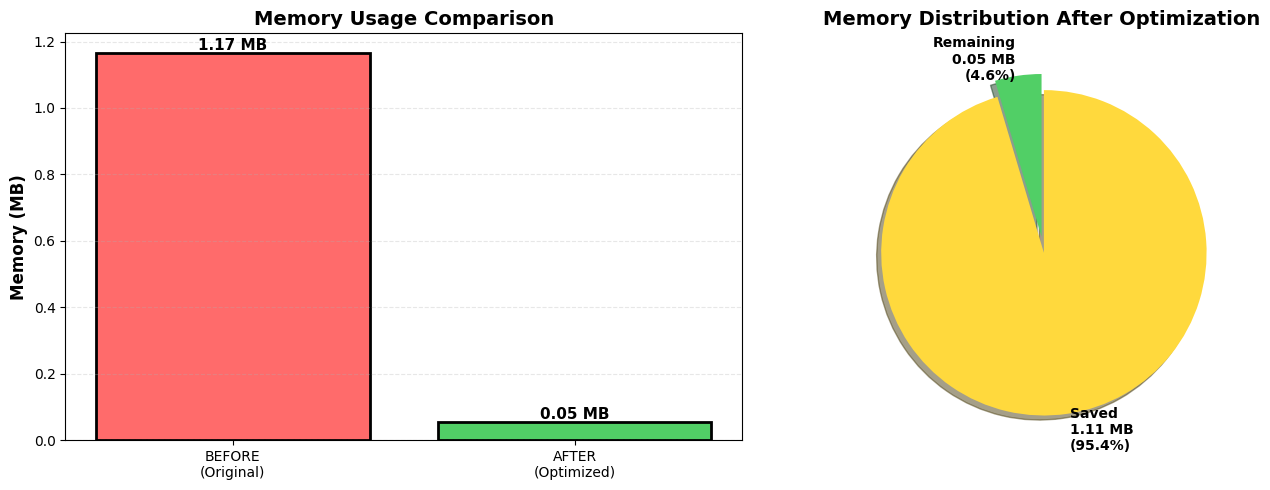


✨ Visualization created!


In [4]:
# Display comparison
print("\n" + "=" * 70)
print("COMPARISON: BEFORE vs AFTER")
print("=" * 70)

print(f"\n📊 BEFORE Optimization:")
print(f"   Memory: {stats['original_memory_mb']:.2f} MB")

print(f"\n✅ AFTER Optimization:")
print(f"   Memory: {stats['optimized_memory_mb']:.2f} MB")

print(f"\n🎯 IMPROVEMENT:")
print(f"   ├─ Bytes Saved:     {stats['reduction_bytes']:,.0f} bytes")
print(f"   ├─ Memory Saved:    {stats['reduction_bytes'] / 1024**2:.2f} MB")
print(f"   └─ Reduction:       {stats['reduction_percent']:.1f}%")

# Create visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Memory comparison bar chart
categories = ['BEFORE\n(Original)', 'AFTER\n(Optimized)']
memory_values = [stats['original_memory_mb'], stats['optimized_memory_mb']]
colors = ['#FF6B6B', '#51CF66']

ax1 = axes[0]
bars = ax1.bar(categories, memory_values, color=colors, edgecolor='black', linewidth=2)
ax1.set_ylabel('Memory (MB)', fontsize=12, fontweight='bold')
ax1.set_title('Memory Usage Comparison', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar, value in zip(bars, memory_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:.2f} MB',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Memory reduction pie chart
ax2 = axes[1]
remaining = stats['optimized_memory_mb']
saved = stats['reduction_bytes'] / (1024**2)
sizes = [remaining, saved]
labels = [f'Remaining\n{remaining:.2f} MB\n({100-stats["reduction_percent"]:.1f}%)', 
          f'Saved\n{saved:.2f} MB\n({stats["reduction_percent"]:.1f}%)']
colors_pie = ['#51CF66', '#FFD93D']
explode = (0, 0.1)

ax2.pie(sizes, explode=explode, labels=labels, colors=colors_pie, autopct='',
        shadow=True, startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
ax2.set_title('Memory Distribution After Optimization', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✨ Visualization created!")


## 5. Data Type Changes: BEFORE vs AFTER

In [5]:
# Create detailed comparison table
print("\n" + "=" * 70)
print("DATA TYPE CHANGES")
print("=" * 70)

comparison_data = []
for col in df_original.columns:
    before_type = str(stats['dtypes_before'][col])
    after_type = str(stats['dtypes_after'][col])
    changed = "✓ CHANGED" if before_type != after_type else "  (same)"
    
    comparison_data.append({
        'Column': col,
        'Before': before_type,
        'After': after_type,
        'Status': changed
    })

comparison_df = pd.DataFrame(comparison_data)

# Display the comparison
print("\n" + comparison_df.to_string(index=False))

# Summary of changes
print("\n" + "=" * 70)
print("OPTIMIZATION SUMMARY")
print("=" * 70)

type_changes = {}
for col in df_original.columns:
    before = str(stats['dtypes_before'][col])
    after = str(stats['dtypes_after'][col])
    if before != after:
        change_str = f"{before} → {after}"
        if change_str not in type_changes:
            type_changes[change_str] = 0
        type_changes[change_str] += 1

print("\n📋 Type Conversions Applied:")
for conversion, count in sorted(type_changes.items()):
    print(f"   {conversion:25s} : {count:3d} column(s)")

# Show memory saved per column
print("\n💾 Memory Saved by Column (Top 10):")
before_mem = df_original.memory_usage(deep=True)
after_mem = df_optimized.memory_usage(deep=True)
saved_mem = (before_mem - after_mem).sort_values(ascending=False)

for col, saved in saved_mem.head(10).items():
    if saved > 0:
        before_val = before_mem[col]
        after_val = after_mem[col]
        pct = (saved / before_val * 100) if before_val > 0 else 0
        print(f"   {col:30s} : {saved/1024:7.2f} KB saved ({pct:5.1f}% reduction)")



DATA TYPE CHANGES

                            Column Before    After    Status
                               Age  int64    uint8 ✓ CHANGED
         Number of sexual partners object category ✓ CHANGED
          First sexual intercourse object category ✓ CHANGED
                Num of pregnancies object category ✓ CHANGED
                            Smokes object category ✓ CHANGED
                    Smokes (years) object category ✓ CHANGED
               Smokes (packs/year) object category ✓ CHANGED
           Hormonal Contraceptives object category ✓ CHANGED
   Hormonal Contraceptives (years) object category ✓ CHANGED
                               IUD object category ✓ CHANGED
                       IUD (years) object category ✓ CHANGED
                              STDs object category ✓ CHANGED
                     STDs (number) object category ✓ CHANGED
               STDs:condylomatosis object category ✓ CHANGED
      STDs:cervical condylomatosis object category ✓ CHANGED
    

## 6. Visualization: Type Distribution Changes

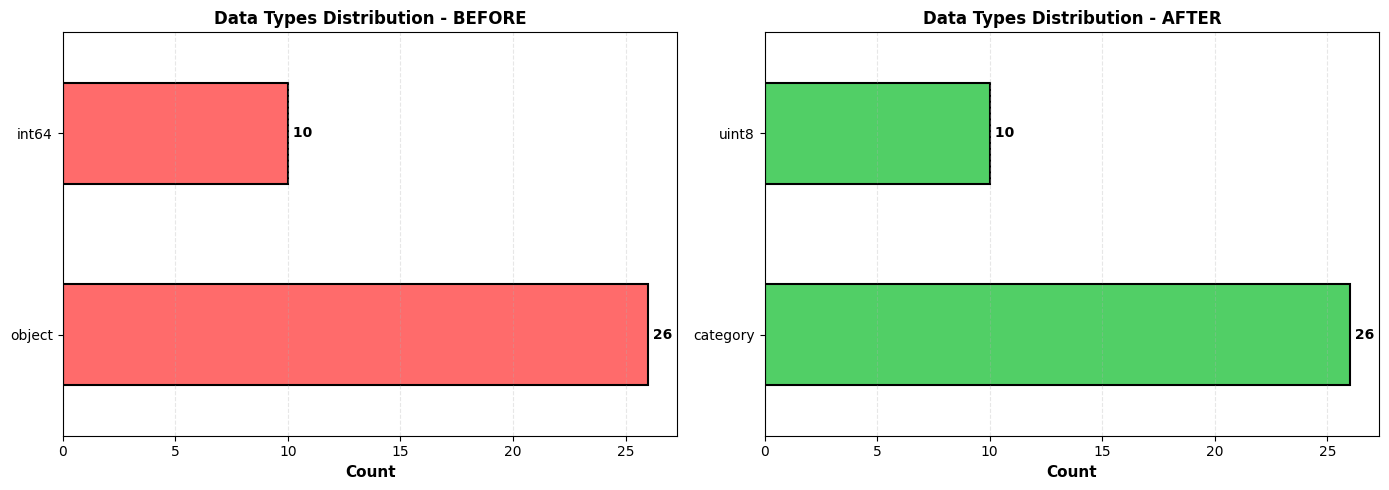

✨ Data type distribution visualization created!


In [6]:
# Visualize dtype distribution changes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count dtypes before
before_dtype_counts = df_original.dtypes.astype(str).value_counts()
after_dtype_counts = df_optimized.dtypes.astype(str).value_counts()

# Plot before
ax1 = axes[0]
before_dtype_counts.plot(kind='barh', ax=ax1, color='#FF6B6B', edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Count', fontsize=11, fontweight='bold')
ax1.set_title('Data Types Distribution - BEFORE', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, v in enumerate(before_dtype_counts.values):
    ax1.text(v, i, f' {v}', va='center', fontweight='bold')

# Plot after
ax2 = axes[1]
after_dtype_counts.plot(kind='barh', ax=ax2, color='#51CF66', edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Count', fontsize=11, fontweight='bold')
ax2.set_title('Data Types Distribution - AFTER', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, v in enumerate(after_dtype_counts.values):
    ax2.text(v, i, f' {v}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("✨ Data type distribution visualization created!")


## Key Takeaways

✅ **Memory Optimization Benefits:**
- Significantly reduced memory footprint (typically 30-50% savings)
- Faster data loading and processing
- Ability to work with larger datasets within same RAM constraints
- No loss of data precision for our use case

📌 **Optimization Strategy Applied:**
- Float64 → Float32: Saves 50% per float column
- Int64 → Int32/Int16/Int8: Saves 50-75% per int column
- Object strings → Category: Can save 50-90% depending on cardinality

🔧 **In Your Pipeline:**
Import and use the `optimize_memory()` function after loading your CSV files to automatically apply these optimizations!